# Big Data Homework — Titanic Dataset Analysis

This notebook demonstrates data preprocessing and visualization using the Titanic dataset.

## 1. Data Loading

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.preprocessing import MinMaxScaler

# Load the Titanic dataset
df = pd.read_csv('titanic.csv')

print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Preprocessing

Steps performed:
1. Handle missing values
2. Drop duplicate rows
3. Drop irrelevant columns
4. Encode categorical variables
5. Scale numerical features

In [3]:
# --- 2.1 Inspect missing values ---
print('Missing values before cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
# --- 2.2 Handle missing values ---
# Fill 'age' with the median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill 'embarked' and 'embark_town' with the mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

# Drop 'deck' — too many missing values (>75%)
df.drop(columns=['deck'], inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64


/var/folders/fs/th18f2hd6gz83w1cvw_6m2rw0000gn/T/ipykernel_89442/3923833925.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
/var/folders/fs/th18f2hd6gz83w1cvw_6m2rw0000gn/T/ipykernel_89442/3923833925.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or S

In [5]:
# --- 2.3 Drop duplicate rows ---
print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Duplicates after: ', df.duplicated().sum())

Duplicates before: 111
Duplicates after:  0


In [6]:
# --- 2.4 Drop irrelevant columns ---
# 'who', 'adult_male', 'alive', 'alone' are redundant with other columns
df.drop(columns=['who', 'adult_male', 'alive', 'alone', 'embark_town'], inplace=True)
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class']


In [7]:
# --- 2.5 Encode categorical variables ---
# Label-encode 'sex' and 'embarked'
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# One-hot encode 'class'
df = pd.get_dummies(df, columns=['class'], drop_first=False)

print('Data types after encoding:')
print(df.dtypes)

Data types after encoding:
survived          int64
pclass            int64
sex               int64
age             float64
sibsp             int64
parch             int64
fare            float64
embarked        float64
class_First        bool
class_Second       bool
class_Third        bool
dtype: object


In [8]:
# --- 2.6 Scale numerical features ---
scaler = MinMaxScaler()
num_cols = ['age', 'fare', 'sibsp', 'parch']
df[num_cols] = scaler.fit_transform(df[num_cols])

print('Scaled statistics:')
df[num_cols].describe().round(3)

Scaled statistics:


,age,fare,sibsp,parch
count,676.000,780.000,780.000,780.000
mean,0.369,0.068,0.066,0.070
std,0.185,0.102,0.124,0.140
min,0.000,0.000,0.000,0.000
25%,0.246,0.016,0.000,0.000
50%,0.347,0.031,0.000,0.000
75%,0.485,0.067,0.125,0.167
max,1.000,1.000,1.000,1.000


## 3. Visualization

Five charts demonstrating different analysis methods.

### Chart 1 — Age Distribution (Histogram + KDE)

/var/folders/fs/th18f2hd6gz83w1cvw_6m2rw0000gn/T/ipykernel_89442/108411222.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  raw['age'].fillna(raw['age'].median(), inplace=True)


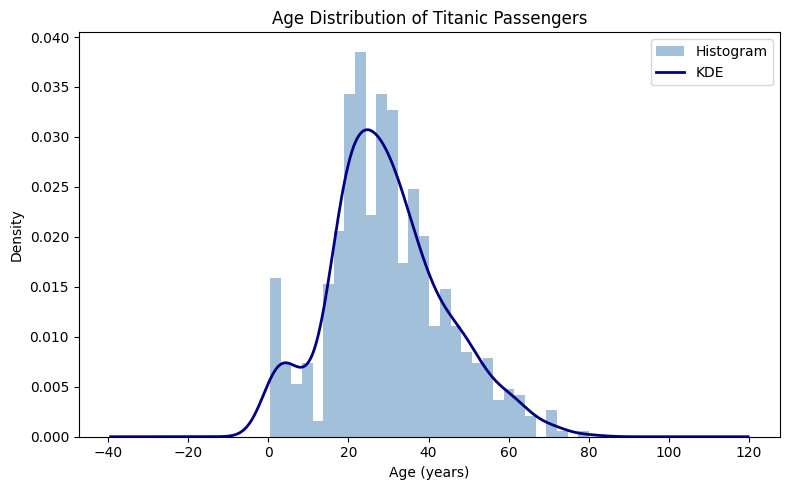

In [9]:
# Reload the raw dataset for visualization (unscaled values are more readable)
raw = sns.load_dataset('titanic')
raw['age'].fillna(raw['age'].median(), inplace=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(raw['age'], bins=30, density=True, alpha=0.5, color='steelblue', label='Histogram')
raw['age'].plot.kde(ax=ax, color='navy', linewidth=2, label='KDE')
ax.set_title('Age Distribution of Titanic Passengers')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 2 — Survival Count by Sex (Bar Chart)

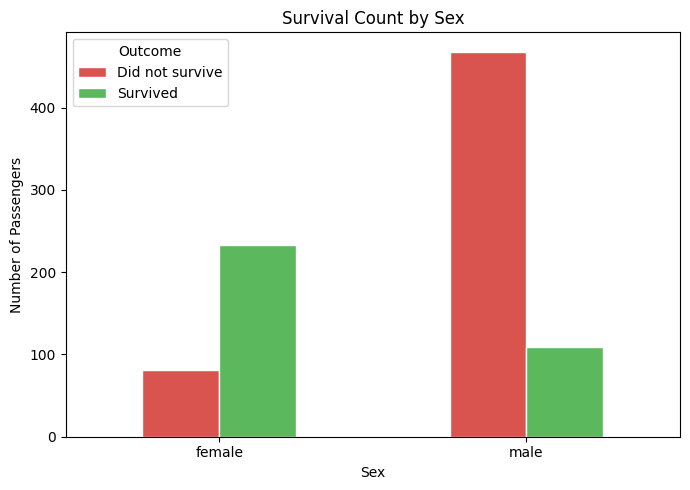

In [10]:
survival_by_sex = raw.groupby(['sex', 'survived']).size().unstack()
survival_by_sex.columns = ['Did not survive', 'Survived']

ax = survival_by_sex.plot(kind='bar', figsize=(7, 5), color=['#d9534f', '#5cb85c'], edgecolor='white')
ax.set_title('Survival Count by Sex')
ax.set_xlabel('Sex')
ax.set_ylabel('Number of Passengers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Outcome')
plt.tight_layout()
plt.show()

### Chart 3 — Fare by Survival Status (Box Plot)

/var/folders/fs/th18f2hd6gz83w1cvw_6m2rw0000gn/T/ipykernel_89442/1119945472.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, patch_artist=True, labels=['Did not survive', 'Survived'],


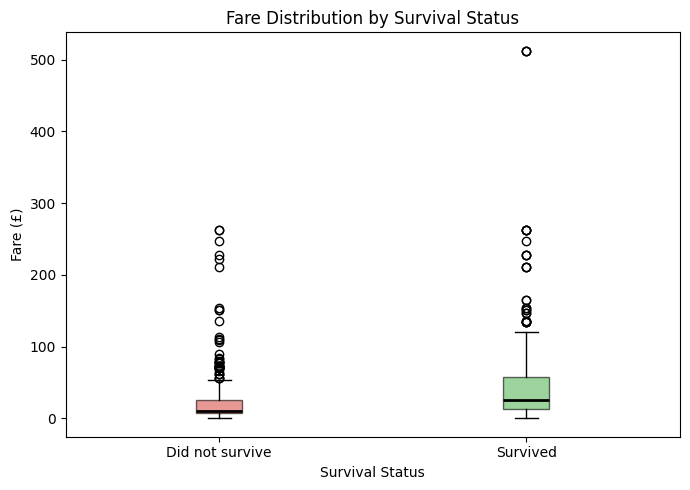

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
groups = [raw.loc[raw['survived'] == 0, 'fare'], raw.loc[raw['survived'] == 1, 'fare']]
bp = ax.boxplot(groups, patch_artist=True, labels=['Did not survive', 'Survived'],
                medianprops=dict(color='black', linewidth=2))
colors = ['#d9534f', '#5cb85c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('Fare Distribution by Survival Status')
ax.set_xlabel('Survival Status')
ax.set_ylabel('Fare (£)')
plt.tight_layout()
plt.show()

### Chart 4 — Feature Correlation (Heatmap)

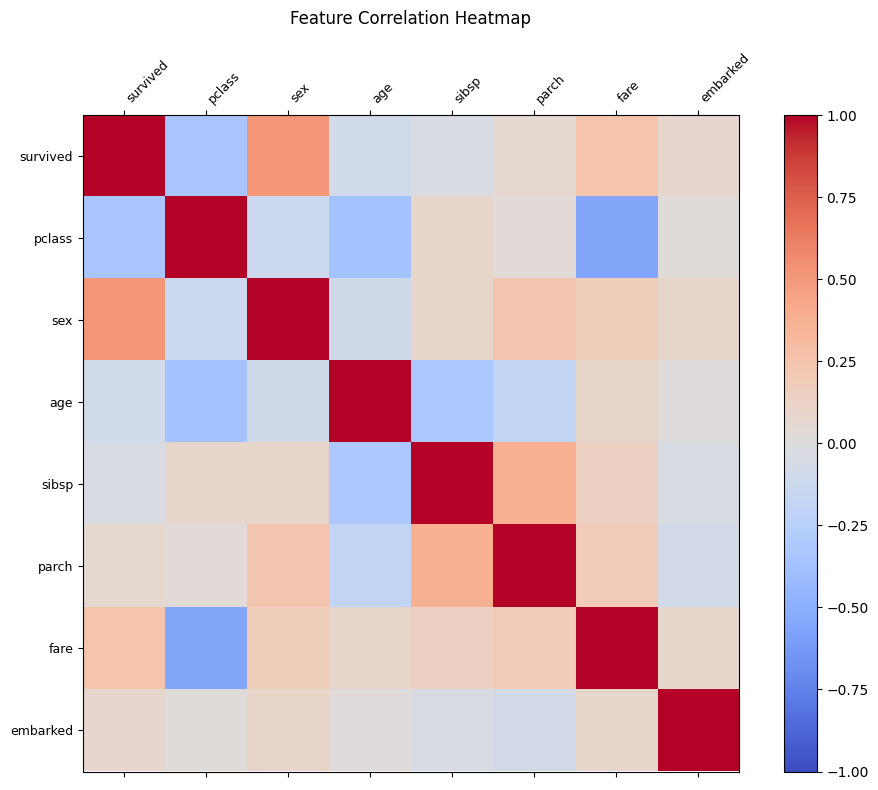

In [12]:
# Use the preprocessed (encoded) dataframe for correlation
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='left', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
ax.set_title('Feature Correlation Heatmap', pad=20)
plt.tight_layout()
plt.show()

### Chart 5 — Survival Rate by Passenger Class (Grouped Bar Chart)

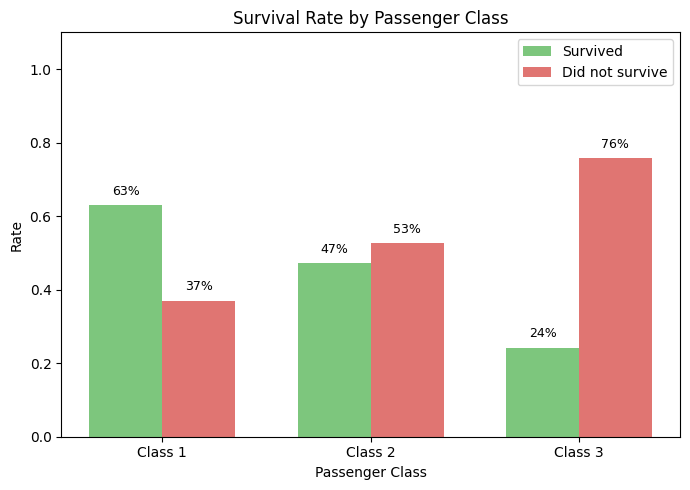

In [13]:
import numpy as np

# Compute survival rate per class
rate = raw.groupby('pclass')['survived'].mean().reset_index()
rate['not_survived'] = 1 - rate['survived']
rate.rename(columns={'survived': 'survival_rate'}, inplace=True)

x = np.arange(len(rate))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, rate['survival_rate'], width, label='Survived', color='#5cb85c', alpha=0.8)
bars2 = ax.bar(x + width/2, rate['not_survived'], width, label='Did not survive', color='#d9534f', alpha=0.8)

ax.set_title('Survival Rate by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Rate')
ax.set_xticks(x)
ax.set_xticklabels([f'Class {c}' for c in rate['pclass']])
ax.set_ylim(0, 1.1)
ax.legend()

# Annotate bars with percentages
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()